**Pipeline:**
1. Load data từ Google Drive
2. Tiền xử lý: rename cột, chuyển label thành số, chia train/test
3. Tải DistilBERT pre-trained, tokenize
4. Fine-tune 3 epochs
5. Đánh giá: accuracy, F1, confusion matrix
6. Lưu model để dùng cho LIME

In [2]:
!pip install -q transformers datasets evaluate accelerate
!pip install -q lime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Tiền xử lý dữ liệu

File Kaggle gốc có:
- Cột `v1`: nhãn `ham` hoặc `spam`
- Cột `v2`: nội dung SMS
- 3 cột thừa `Unnamed: 2`, `Unnamed: 3`, `Unnamed: 4` (chứa toàn NaN)

Ta sẽ:
1. Bỏ các cột thừa
2. Đổi tên `v1` → `label`, `v2` → `text`
3. Chuyển label `ham` → 0, `spam` → 1
4. Bỏ duplicate nếu có

In [4]:

CSV_PATH = "/content/drive/MyDrive/DataSpam/spam.csv"

import pandas as pd


df = pd.read_csv(CSV_PATH, encoding='latin-1')

print("Shape:", df.shape)
print("Cột hiện tại:", df.columns.tolist())
print("\n5 dòng đầu:")
df.head()

Shape: (5572, 5)
Cột hiện tại: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

5 dòng đầu:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
# Chỉ giữ 2 cột v1 và v2
df = df[['v1', 'v2']].copy()

# Đổi tên cột
df.columns = ['label', 'text']

# Bỏ các dòng có giá trị NaN
df = df.dropna()

# Bỏ duplicate
print(f"Trước khi bỏ duplicate: {len(df)}")
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f"Sau khi bỏ duplicate: {len(df)}")

# Chuyển label thành số: ham=0, spam=1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print("\nPhân bố nhãn:")
print(df['label'].value_counts())
print(f"\nTỉ lệ spam: {df['label'].mean()*100:.2f}%")
df.head()

Trước khi bỏ duplicate: 5572
Sau khi bỏ duplicate: 5169

Phân bố nhãn:
label
0    4516
1     653
Name: count, dtype: int64

Tỉ lệ spam: 12.63%


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


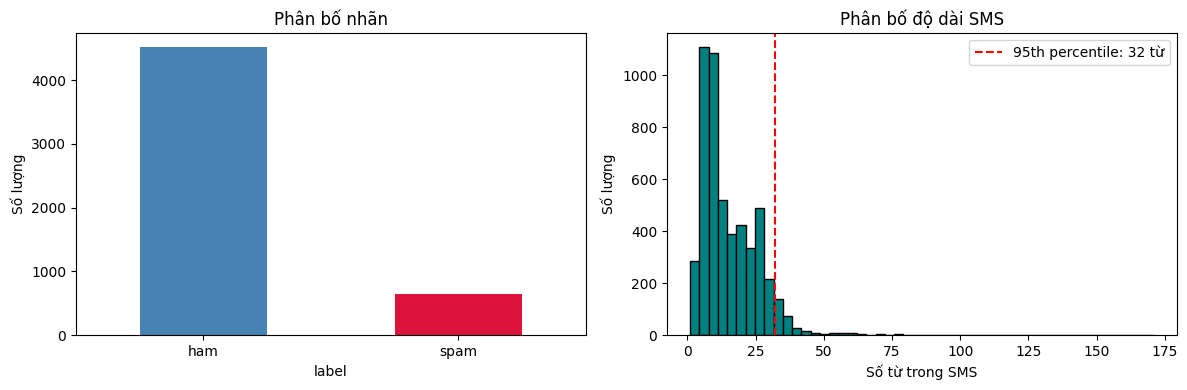

Độ dài trung bình: 15.3 từ
Độ dài tối đa: 171 từ


In [6]:
import matplotlib.pyplot as plt

# Phân bố nhãn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['label'].map({0: 'ham', 1: 'spam'}).value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'crimson']
)
axes[0].set_title('Phân bố nhãn')
axes[0].set_ylabel('Số lượng')
axes[0].tick_params(axis='x', rotation=0)

# Phân bố độ dài
df['length'] = df['text'].apply(lambda x: len(str(x).split()))
axes[1].hist(df['length'], bins=50, edgecolor='black', color='teal')
axes[1].axvline(df['length'].quantile(0.95), color='red', linestyle='--',
                label=f'95th percentile: {df["length"].quantile(0.95):.0f} từ')
axes[1].set_xlabel('Số từ trong SMS')
axes[1].set_ylabel('Số lượng')
axes[1].set_title('Phân bố độ dài SMS')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Độ dài trung bình: {df['length'].mean():.1f} từ")
print(f"Độ dài tối đa: {df['length'].max()} từ")

In [7]:
# Xem vài ví dụ mỗi loại
print("=== Ví dụ HAM ===")
for i in df[df['label']==0]['text'].head(3):
    print(f"  • {i[:120]}")

print("\n=== Ví dụ SPAM ===")
for i in df[df['label']==1]['text'].head(3):
    print(f"  • {i[:120]}")

=== Ví dụ HAM ===
  • Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
  • Ok lar... Joking wif u oni...
  • U dun say so early hor... U c already then say...

=== Ví dụ SPAM ===
  • Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt r
  • FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std
  • WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. 


In [8]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df[['text', 'label']],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} mẫu ({train_df['label'].mean()*100:.1f}% spam)")
print(f"Test:  {len(test_df)} mẫu ({test_df['label'].mean()*100:.1f}% spam)")

Train: 4135 mẫu (12.6% spam)
Test:  1034 mẫu (12.7% spam)


In [9]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

print(train_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 4135
})


In [10]:
#Tokenize
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Test tokenizer
sample = "Free entry to win iPhone now!"
tokens = tokenizer(sample)
print("Input:", sample)
print("Token IDs:", tokens['input_ids'])
print("Tokens:", tokenizer.convert_ids_to_tokens(tokens['input_ids']))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Input: Free entry to win iPhone now!
Token IDs: [101, 2489, 4443, 2000, 2663, 18059, 2085, 999, 102]
Tokens: ['[CLS]', 'free', 'entry', 'to', 'win', 'iphone', 'now', '!', '[SEP]']


In [11]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

print("✅ Đã tokenize xong")
print("Features:", train_tokenized.column_names)

Map:   0%|          | 0/4135 [00:00<?, ? examples/s]

Map:   0%|          | 0/1034 [00:00<?, ? examples/s]

✅ Đã tokenize xong
Features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']




`num_labels=2` vì có 2 lớp: ham và spam.

Lúc này:
- Backbone DistilBERT đã pre-trained (biết tiếng Anh)
- Classifier head (2 outputs) khởi tạo random
- Fine-tune sẽ huấn luyện toàn bộ model

In [12]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "ham", 1: "spam"},
    label2id={"ham": 0, "spam": 1}
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Tổng tham số:    {total_params:,}")
print(f"Tham số trainable: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tổng tham số:    66,955,010
Tham số trainable: 66,955,010


In [13]:
import numpy as np
import evaluate

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        "accuracy": accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"],
        "f1": f1_metric.compute(predictions=predictions, references=labels)["f1"]
    }

In [14]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./distilbert-spam",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    save_total_limit=1
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

print("✅ Đã setup Trainer")

✅ Đã setup Trainer


In [15]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.068463,0.039897,0.988395,0.953846
2,0.027086,0.035095,0.988395,0.953846
3,0.040981,0.034452,0.990329,0.961240


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=777, training_loss=0.046332214137915634, metrics={'train_runtime': 183.4761, 'train_samples_per_second': 67.611, 'train_steps_per_second': 4.235, 'total_flos': 410814520081920.0, 'train_loss': 0.046332214137915634, 'epoch': 3.0})

In [16]:
# Đánh giá tổng quát
results = trainer.evaluate()
print("=== Kết quả trên Test Set ===")
for k, v in results.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")

=== Kết quả trên Test Set ===
  eval_loss: 0.0345
  eval_accuracy: 0.9903
  eval_f1: 0.9612
  eval_runtime: 5.1918
  eval_samples_per_second: 199.1600
  eval_steps_per_second: 6.3560
  epoch: 3.0000


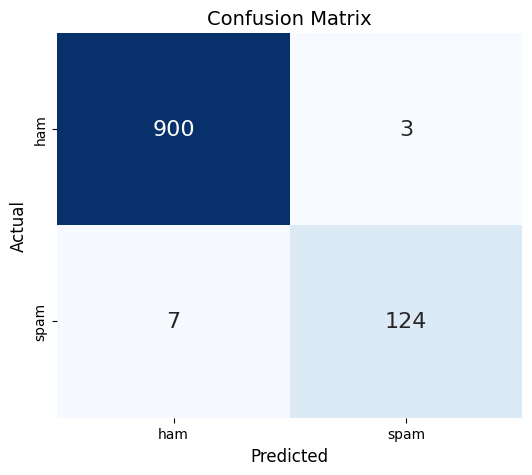


=== Classification Report ===
              precision    recall  f1-score   support

         ham     0.9923    0.9967    0.9945       903
        spam     0.9764    0.9466    0.9612       131

    accuracy                         0.9903      1034
   macro avg     0.9843    0.9716    0.9779      1034
weighted avg     0.9903    0.9903    0.9903      1034



In [17]:
# Confusion matrix + classification report
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

predictions = trainer.predict(test_tokenized)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam'],
            yticklabels=['ham', 'spam'],
            cbar=False, annot_kws={"size": 16})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=['ham', 'spam'], digits=4))

In [18]:
# Tìm các mẫu bị dự đoán sai
test_results_df = test_df.copy()
test_results_df['predicted'] = y_pred
test_results_df['actual'] = y_true

wrong = test_results_df[test_results_df['predicted'] != test_results_df['actual']]
print(f"Tổng số mẫu sai: {len(wrong)} / {len(test_results_df)}")

# False Positives (ham bị nhận nhầm thành spam)
fp = wrong[wrong['actual'] == 0]
print(f"\n--- False Positives (ham → spam): {len(fp)} ---")
for i, row in fp.head(5).iterrows():
    print(f"  • {row['text'][:120]}")

# False Negatives (spam bị bỏ sót)
fn = wrong[wrong['actual'] == 1]
print(f"\n--- False Negatives (spam → ham): {len(fn)} ---")
for i, row in fn.head(5).iterrows():
    print(f"  • {row['text'][:120]}")

Tổng số mẫu sai: 10 / 1034

--- False Positives (ham → spam): 3 ---
  • Camera quite good, 10.1mega pixels, 3optical and 5digital dooms. Have a lovely holiday, be safe and i hope you hav a goo
  • Your bill at 3 is å£33.65 so thats not bad!
  • V nice! Off 2 sheffield tom 2 air my opinions on categories 2 b used 2 measure ethnicity in next census. Busy transcribi

--- False Negatives (spam → ham): 7 ---
  • Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rude time with a sexy bitch. How about we g
  • In The Simpsons Movie released in July 2007 name the band that died at the start of the film? A-Green Day, B-Blue Day, C
  • RECPT 1/3. You have ordered a Ringtone. Your order is being processed...
  • Xmas & New Years Eve tickets are now on sale from the club, during the day from 10am till 8pm, and on Thurs, Fri & Sat n
  • Latest News! Police station toilet stolen, cops have nothing to go on!


In [19]:
SAVE_PATH = "/content/drive/MyDrive/distilbert-spam"

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"✅ Đã lưu model vào: {SAVE_PATH}")
print("\nLần sau load lại bằng:")
print(f"  model = AutoModelForSequenceClassification.from_pretrained('{SAVE_PATH}')")
print(f"  tokenizer = AutoTokenizer.from_pretrained('{SAVE_PATH}')")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Đã lưu model vào: /content/drive/MyDrive/distilbert-spam

Lần sau load lại bằng:
  model = AutoModelForSequenceClassification.from_pretrained('/content/drive/MyDrive/distilbert-spam')
  tokenizer = AutoTokenizer.from_pretrained('/content/drive/MyDrive/distilbert-spam')


In [22]:
import torch
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

test_messages = [
    "Hey, are we still meeting at 3pm tomorrow?",
    "WINNER!! You've won $1000! Click here to claim now!",
    "Mom, I'll be home late tonight",
    "URGENT! Your account will be suspended. Reply YES to verify.",
    "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005",
    "I'll call you when I get home, love you",
    "Congratulations! You have been selected for a $500 gift card. Text WIN to 12345"
]

print("=== Kết quả phân loại ===\n")
for text in test_messages:
    result = classifier(text)[0]
    label = result['label'].upper()
    score = result['score']
    icon = "🚫" if label == "SPAM" else "✅"
    print(f"{icon} [{label}] ({score:.2%})")
    print(f"   {text}\n")

=== Kết quả phân loại ===

✅ [HAM] (99.87%)
   Hey, are we still meeting at 3pm tomorrow?

🚫 [SPAM] (98.89%)
   WINNER!! You've won $1000! Click here to claim now!

✅ [HAM] (99.93%)
   Mom, I'll be home late tonight

🚫 [SPAM] (91.08%)
   URGENT! Your account will be suspended. Reply YES to verify.

🚫 [SPAM] (99.71%)
   Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005

✅ [HAM] (99.93%)
   I'll call you when I get home, love you

🚫 [SPAM] (99.84%)
   Congratulations! You have been selected for a $500 gift card. Text WIN to 12345

